# House Price Prediction (Penalized Linear Regression)

In [1]:
url = 'https://raw.githubusercontent.com/dana-fatemeh/Final-ML-Project/main/Data/train.csv'

import pandas as pd
import numpy as np

data = pd.read_csv(url)
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


## Preprocessing


In [2]:
data = data.drop(columns=['Id'])

data['Has_Alley'] = data['Alley'].notna().astype(int)
data = data.drop(columns=['Alley'])

data['LotFrontage'] = data['LotFrontage'].fillna(0)
data['MasVnrArea'] = data['MasVnrArea'].fillna(0)

# MasVnrType: Masonry veneer type
# BsmtQual: Evaluates the height of the basement
# BsmtCond: Evaluates the general condition of the basement
# BsmtExposure: Refers to walkout or garden level walls
# BsmtFinType1: Rating of basement finished area
# BsmtFinType2: Rating of basement finished area (if multiple types)
# FireplaceQu: Fireplace quality
# GarageType: Garage location
# GarageFinish: Interior finish of the garage
# GarageQual: Garage quality
# GarageCond: Garage condition
# PoolQC: Pool quality
# Fence: Fence quality
# MiscFeature: Miscellaneous feature not covered in other categories

none_cols = ['MasVnrType','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
             'FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond','PoolQC','Fence','MiscFeature']

for col in none_cols:
    data[col] = data[col].fillna('None')

data['GarageYrBlt'] = data['GarageYrBlt'].fillna(0)
data['GarageYrBlt'] = data['GarageYrBlt'].fillna(0)
data['Electrical'] = data['Electrical'].fillna(0)

qual_rate = {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1, 'None':0} # Maybe change None to -1
ord_cols = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC','KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']
for col in ord_cols:
    data[col+'_ord'] = data[col].map(qual_rate)
    data = data.drop(columns=[col])

data['LandContour'] = data['LandContour'].map({'Lvl':2, 'Bnk':3, 'HLS':4, 'Low':1}) # Maybe Change
data['LandSlope'] = data['LandSlope'].map({'Gtl':1, 'Mod':2, 'Sev':5})
data['BsmtExposure'] = data['BsmtExposure'].map({'Gd':10, 'Av':6, 'Mn':3, 'No':1, 'None':0})
data['BsmtFinType1'] = data['BsmtFinType1'].map({'GLQ':10, 'ALQ':7, 'BLQ':3, 'Rec':5, 'LwQ':2, 'Unf':1, 'None':0})
data['BsmtFinType2'] = data['BsmtFinType2'].map({'GLQ':10, 'ALQ':7, 'BLQ':3, 'Rec':5, 'LwQ':2, 'Unf':1, 'None':0})
data['CentralAir'] = data['CentralAir'].map({'Y':1, 'N':0})
data['Electrical'] = data['Electrical'].map({'SBrkr':10, 'FuseA':7, 'FuseF':3, 'FuseP':1, 'Mix':5})
data['Functional'] = data['Functional'].map({'Typ':10, 'Min1':9, 'Min2':8, 'Mod':5, 'Maj1':3, 'Maj2':2, 'Sev':1, 'Sal':0})
data['GarageFinish'] = data['GarageFinish'].map({'Fin':5, 'RFn':2, 'Unf':1, 'None':0})
data['Fence'] = data['Fence'].map({'GdPrv':5, 'MnPrv':3, 'GdWo':2, 'MnWw':1, 'None':0})

data = data.drop(columns=['Utilities']) # Maybe Ordinal


categorical_cols = ['MSZoning','Street','LotShape','LotConfig','Neighborhood',
                'Condition1','Condition2','BldgType','HouseStyle','RoofStyle','RoofMatl','Exterior1st','Exterior2nd','MasVnrType',
                'Foundation','Heating','CentralAir','GarageType','PavedDrive','MiscFeature',
                'SaleType','SaleCondition']

data = pd.get_dummies(data, columns=[col for col in categorical_cols], dtype=int)


data['TotalBathrooms'] = data['FullBath'] + 0.5*data['HalfBath'] + data['BsmtFullBath'] + 0.5*data['BsmtHalfBath']
data['Age'] = 2009 - data['YearBuilt']
data['RemodAge'] = 2009 - data['YearRemodAdd']
data['IsRemodeled'] = (data['YearBuilt'] != data['YearRemodAdd']).astype(int)
data['GoodTotalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['WoodDeckSF'] + data['OpenPorchSF'] + data['2ndFlrSF'] - data['LowQualFinSF']
data['TotalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['2ndFlrSF'] + data['WoodDeckSF'] + data['OpenPorchSF']


data

,MSSubClass,LotFrontage,LotArea,LandContour,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,TotalBathrooms,Age,RemodAge,IsRemodeled,GoodTotalSF,TotalSF
0,60,65.0,8450,2,1,7,5,2003,2003,196.0,...,0,0,1,0,3.5,6,6,0,2627,2627
1,20,80.0,9600,2,1,6,8,1976,1976,0.0,...,0,0,1,0,2.5,33,33,0,2822,2822
2,60,68.0,11250,2,1,7,5,2001,2002,162.0,...,0,0,1,0,3.5,8,7,1,2748,2748
3,70,60.0,9550,2,1,7,5,1915,1970,0.0,...,0,0,0,0,2.0,94,39,1,2508,2508
4,60,84.0,14260,2,1,8,5,2000,2000,350.0,...,0,0,1,0,3.5,9,9,0,3619,3619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,62.0,7917,2,1,6,5,1999,2000,0.0,...,0,0,1,0,2.5,10,9,1,2640,2640
1456,20,85.0,13175,2,1,6,6,1978,1988,119.0,...,0,0,1,0,3.0,31,21,1,3964,3964
1457,70,66.0,9042,2,1,7,9,1941,2006,0.0,...,0,0,1,0,2.0,68,3,1,3552,3552
1458,20,68.0,9717,2,1,5,6,1950,1996,0.0,...,0,0,1,0,2.0,59,13,1,2522,2522


## Train / Test Split
 80/20 split

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tabulate import tabulate


y = data['SalePrice']
X = data.drop(columns=['SalePrice'])

# Impute then scale
imputer = SimpleImputer(strategy='most_frequent')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Outer split
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_scaled, y.values, test_size=0.2, random_state=1234)

# Inner split
X_train, X_test, y_train, y_test = train_test_split(
    X_train_h, y_train_h, test_size=0.2, random_state=1234)

print(f'X_train shape: {X_train.shape}')
print(f'X_test  shape: {X_test.shape}')

X_train shape: (934, 226)
X_test  shape: (234, 226)


## Penalized Linear Regression Model

Adds a penalty term to the loss function that discourages the model from assigning large coefficients to features

In [4]:
from sklearn.linear_model import ElasticNetCV

lr_model = ElasticNetCV(
    alphas=[0.1, 1.0, 10.0, 100.0, 1000.0],
    # alphas regularization penalty; how much the coefficients are penalized; follows log scale
    # l1 Lasso:  penalizes the sum of absolute values of coefficients
    # l2 Ridge: penalizes the sum of squared coefficients
    # l1_ratio is mix of both
    l1_ratio=[0.1, 0.5, 0.7, 0.9, 1.0],  # mix between L1 and L2 (1.0 = pure Lasso, 0.0 = pure Ridge)
    cv=5 #5 fold
)
lr_model.fit(X_train, y_train)

print(f'Best alpha: {lr_model.alpha_}')
print(f'Best l1_ratio: {lr_model.l1_ratio_}')
print(f'Non-zero coefficients: {(lr_model.coef_ != 0).sum()} / {len(lr_model.coef_)}')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 20225834979.31967, tolerance: 482283106.1315615
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 15213388775.244598, tolerance: 476525689.8211544
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 8779293383.91449, tolerance: 486099839.53654706
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWa

Best alpha: 1.0
Best l1_ratio: 0.5
Non-zero coefficients: 222 / 226


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 110901630025.89746, tolerance: 481609103.6976678
  model = cd_fast.enet_coordinate_descent_gram(


## Evaluation
Metrics: MAE, MSE, RMSE, R²

In [5]:
# Predictions
y_train_pred = lr_model.predict(X_train)
y_test_pred  = lr_model.predict(X_test)

# Metrics
MAE_train  = mean_absolute_error(y_train, y_train_pred)
MSE_train  = mean_squared_error(y_train, y_train_pred)
RMSE_train = np.sqrt(MSE_train)
R2_train   = r2_score(y_train, y_train_pred)

MAE_test   = mean_absolute_error(y_test, y_test_pred)
MSE_test   = mean_squared_error(y_test, y_test_pred)
RMSE_test  = np.sqrt(MSE_test)
R2_test    = r2_score(y_test, y_test_pred)

results = []
results.append(["LinearReg", MAE_train, MSE_train, RMSE_train, R2_train,
                MAE_test,  MSE_test,  RMSE_test,  R2_test])

print(tabulate(results,
               headers=["Model", "Train MAE", "Train MSE", "Train RMSE", "Train R²",
                        "Test MAE", "Test MSE", "Test RMSE", "Test R²"],
               tablefmt="grid",
               floatfmt='.4f'))

+-----------+-------------+----------------+--------------+------------+------------+----------------+-------------+-----------+
| Model     |   Train MAE |      Train MSE |   Train RMSE |   Train R² |   Test MAE |       Test MSE |   Test RMSE |   Test R² |
+===========+=============+================+==============+============+============+================+=============+===========+
| LinearReg |  15565.0939 | 664392608.7041 |   25775.8144 |     0.8982 | 15848.6520 | 587885212.6876 |  24246.3443 |    0.9084 |
+-----------+-------------+----------------+--------------+------------+------------+----------------+-------------+-----------+


## Residual Plot
Visualize how far off the predictions are on the test set.

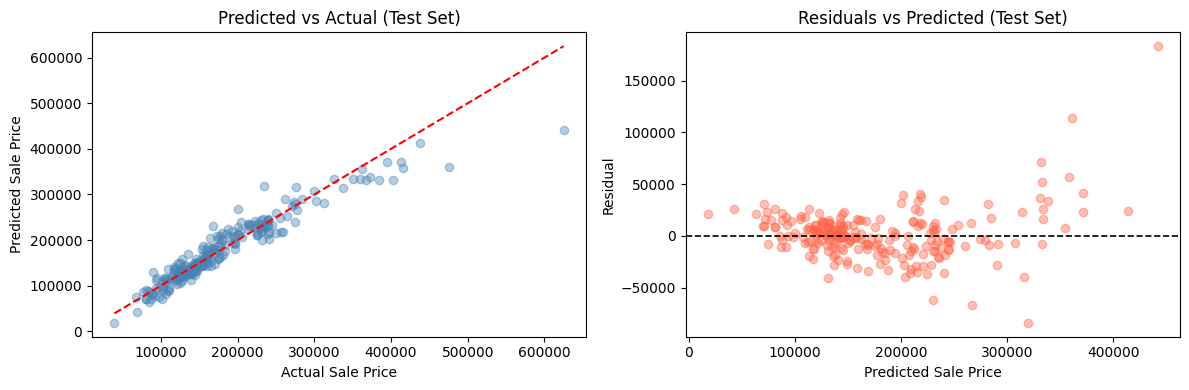

In [6]:
import matplotlib.pyplot as plt

residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Predicted vs Actual
axes[0].scatter(y_test, y_test_pred, alpha=0.4, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Sale Price')
axes[0].set_ylabel('Predicted Sale Price')
axes[0].set_title('Predicted vs Actual (Test Set)')

# Residuals
axes[1].scatter(y_test_pred, residuals, alpha=0.4, color='tomato')
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Predicted Sale Price')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted (Test Set)')

plt.tight_layout()
plt.show()

## Most Influential Features (comparing coefficients)

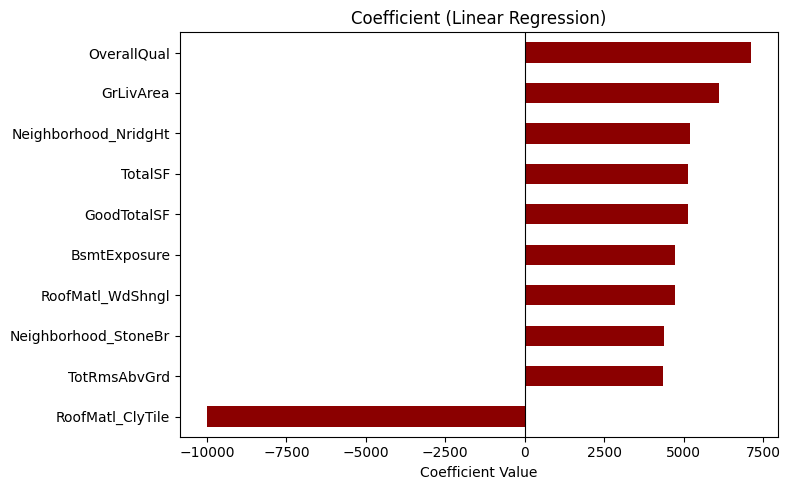

In [7]:
feature_names = X.columns.tolist()
coef_series = pd.Series(lr_model.coef_, index=feature_names)
top10 = coef_series.abs().nlargest(10).index

plt.figure(figsize=(8, 5))
coef_series[top10].sort_values().plot(kind='barh', color='darkred')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coefficient (Linear Regression)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

In [8]:
print(coef_series)

MSSubClass    -2006.506787
LotFrontage     789.810753
LotArea        1426.482742
LandContour     367.872753
LandSlope      -253.471791
                  ...     
Age           -1338.932078
RemodAge      -1068.977697
IsRemodeled    1549.018877
GoodTotalSF    5142.282297
TotalSF        5143.951203
Length: 226, dtype: float64
